In [3]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [4]:
import cooler
import cooltools

In [5]:
# to print which resolutions are stored in the mcool, use list_coolers
cooler.fileops.list_coolers("/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool")

['/resolutions/5000',
 '/resolutions/10000',
 '/resolutions/25000',
 '/resolutions/50000',
 '/resolutions/100000',
 '/resolutions/250000',
 '/resolutions/500000',
 '/resolutions/1000000',
 '/resolutions/2500000',
 '/resolutions/5000000']

In [6]:
cooler.fileops.list_coolers("/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool")

['/resolutions/5000',
 '/resolutions/10000',
 '/resolutions/25000',
 '/resolutions/50000',
 '/resolutions/100000',
 '/resolutions/250000',
 '/resolutions/500000',
 '/resolutions/1000000',
 '/resolutions/2500000',
 '/resolutions/5000000']

In [7]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations
import os

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import numpy as np
import pandas as pd
from multiprocessing import Pool

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorial relies on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

# count cpus
num_cpus = os.getenv('SLURM_CPUS_PER_TASK')
if not num_cpus:
    num_cpus = os.cpu_count()
num_cpus = int(num_cpus)

In [8]:
### to load a cooler with a specific resolution use the following syntax:
clr_1 = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/5000")
clr_2 = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/5000")

In [9]:
# chrom.sizes
chromsizes = pd.read_csv('/usr/users/papantonis1/aman/chrom.sizes', sep='\t')

In [10]:
# Use bioframe to fetch the genomic features from the UCSC.
hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
hg38_cens = bioframe.fetch_centromeres('hg38')
# create a view with chromosome arms using chromosome sizes and definition of centromeres
hg38_arms = bioframe.make_chromarms(hg38_chromsizes,  hg38_cens)

# select only those chromosomes available in cooler
hg38_arms = hg38_arms[hg38_arms.chrom.isin(clr_1.chromnames)].reset_index(drop=True)
hg38_arms

,chrom,start,end,name
0,chr1,0,123400000,chr1_p
1,chr1,123400000,248956422,chr1_q
2,chr2,0,93900000,chr2_p
3,chr2,93900000,242193529,chr2_q
4,chr3,0,90900000,chr3_p
5,chr3,90900000,198295559,chr3_q
6,chr4,0,50000000,chr4_p
7,chr4,50000000,190214555,chr4_q
8,chr5,0,48800000,chr5_p
9,chr5,48800000,181538259,chr5_q


In [11]:
# cvd == contacts-vs-distance
cvd = cooltools.expected_cis(
    clr=clr_1,
    view_df=hg38_arms,
    smooth=False,
    aggregate_smoothed=False,
    nproc=num_cpus #if you do not have multiple cores available, set to 1
)

INFO:root:creating a Pool of 48 workers


In [12]:
display(cvd.head(4))
display(cvd.tail(4))

,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg
0,chr1_p,chr1_p,0,0,NaN,24680,22777,NaN,NaN,NaN,NaN
1,chr1_p,chr1_p,1,5000,NaN,24679,22446,NaN,NaN,NaN,NaN
2,chr1_p,chr1_p,2,10000,0.033604,24678,22394,777447.0,752.520084,31.503647,0.033604
3,chr1_p,chr1_p,3,15000,0.020432,24677,22362,473183.0,456.890008,19.175062,0.020432


,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg
617665,chrM_p,chrM_p,0,0,NaN,4,4,NaN,NaN,NaN,NaN
617666,chrM_p,chrM_p,1,5000,NaN,3,3,NaN,NaN,NaN,NaN
617667,chrM_p,chrM_p,2,10000,0.019406,2,2,19.0,0.038813,9.5,0.019406
617668,chrM_p,chrM_p,3,15000,0.061650,1,1,22.0,0.061650,22.0,0.061650


In [13]:
# cvd == contacts-vs-distance
cvd_2 = cooltools.expected_cis(
    clr=clr_2,
    view_df=hg38_arms,
    smooth=False,
    aggregate_smoothed=False,
    nproc=num_cpus #if you do not have multiple cores available, set to 1
)

INFO:root:creating a Pool of 48 workers


In [14]:
display(cvd_2.head(4))
display(cvd_2.tail(4))

,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg
0,chr1_p,chr1_p,0,0,NaN,24680,22698,NaN,NaN,NaN,NaN
1,chr1_p,chr1_p,1,5000,NaN,24679,22308,NaN,NaN,NaN,NaN
2,chr1_p,chr1_p,2,10000,0.033957,24678,22251,888712.0,755.580060,36.012319,0.033957
3,chr1_p,chr1_p,3,15000,0.020646,24677,22227,541568.0,458.897702,21.946266,0.020646


,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg
617665,chrM_p,chrM_p,0,0,NaN,4,4,NaN,NaN,NaN,NaN
617666,chrM_p,chrM_p,1,5000,NaN,3,3,NaN,NaN,NaN,NaN
617667,chrM_p,chrM_p,2,10000,0.051045,2,2,38.0,0.102090,19.0,0.051045
617668,chrM_p,chrM_p,3,15000,0.074952,1,1,22.0,0.074952,22.0,0.074952


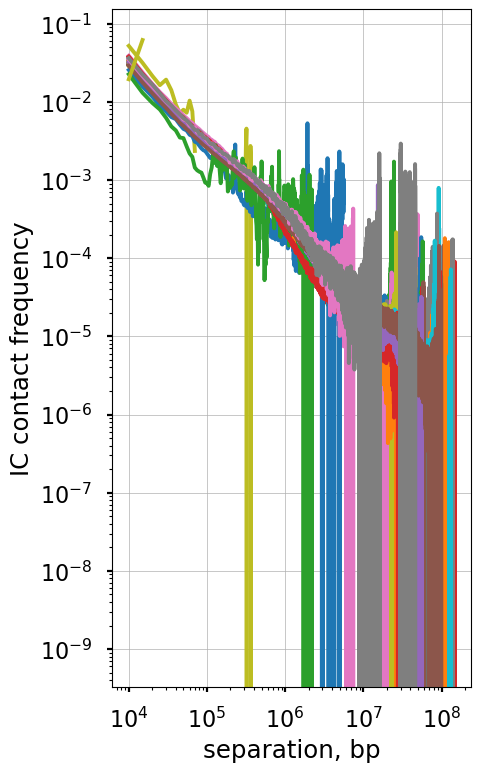

In [15]:
f, ax = plt.subplots(1,1)

for region in hg38_arms['name']:
    ax.loglog(
        cvd['dist_bp'].loc[cvd['region1']==region],
        cvd['contact_frequency'].loc[cvd['region1']==region],
    )
    ax.set(
        xlabel='separation, bp',
        ylabel='IC contact frequency')
    ax.set_aspect(1.0)
    ax.grid(lw=0.5)

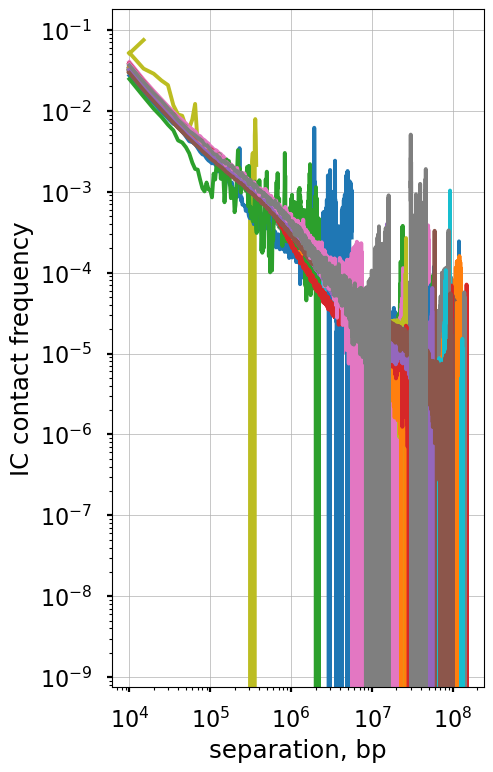

In [16]:
f, ax = plt.subplots(1,1)

for region in hg38_arms['name']:
    ax.loglog(
        cvd_2['dist_bp'].loc[cvd_2['region1']==region],
        cvd_2['contact_frequency'].loc[cvd_2['region1']==region],
    )
    ax.set(
        xlabel='separation, bp',
        ylabel='IC contact frequency')
    ax.set_aspect(1.0)
    ax.grid(lw=0.5)

In [17]:
#Smoothing & aggregating P(s) curves
cvd_smooth_agg_1 = cooltools.expected_cis(
    clr=clr_1,
    view_df=hg38_arms,
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    nproc=num_cpus
)

INFO:root:creating a Pool of 48 workers


In [19]:
display(cvd_smooth_agg_1.head(4))

,region1,region2,dist,dist_bp,contact_frequency,n_total,n_valid,count.sum,balanced.sum,count.avg,balanced.avg,balanced.avg.smoothed,balanced.avg.smoothed.agg
0,chr1_p,chr1_p,0,0,NaN,24680,22777,NaN,NaN,NaN,NaN,NaN,NaN
1,chr1_p,chr1_p,1,5000,0.000340,24679,22446,NaN,NaN,NaN,NaN,0.000357,0.000340
2,chr1_p,chr1_p,2,10000,0.029384,24678,22394,777447.0,752.520084,31.503647,0.033604,0.030876,0.029384
3,chr1_p,chr1_p,3,15000,0.019113,24677,22362,473183.0,456.890008,19.175062,0.020432,0.020018,0.019113


In [18]:
cvd_smooth_agg_2 = cooltools.expected_cis(
    clr=clr_2,
    view_df=hg38_arms,
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    nproc=num_cpus
)

INFO:root:creating a Pool of 48 workers


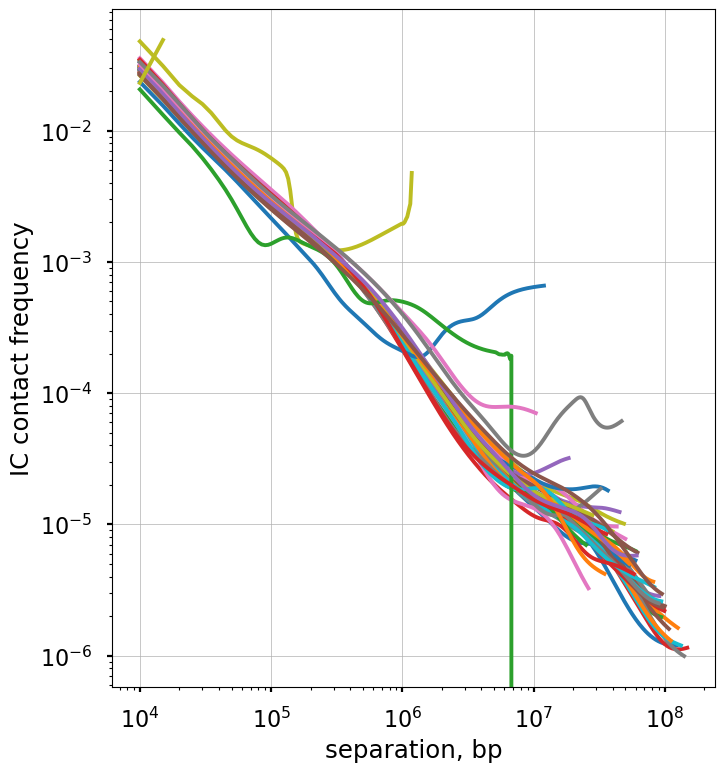

In [20]:
#plotting
cvd_smooth_agg_1['balanced.avg.smoothed'].loc[cvd_smooth_agg_1['dist'] < 2] = np.nan

f, ax = plt.subplots(1,1)

for region in hg38_arms['name']:
    ax.loglog(
        cvd_smooth_agg_1['dist_bp'].loc[cvd_smooth_agg_1['region1']==region],
        cvd_smooth_agg_1['balanced.avg.smoothed'].loc[cvd_smooth_agg_1['region1']==region],
    )
    ax.set(
        xlabel='separation, bp',
        ylabel='IC contact frequency')
    ax.set_aspect(1.0)
    ax.grid(lw=0.5)

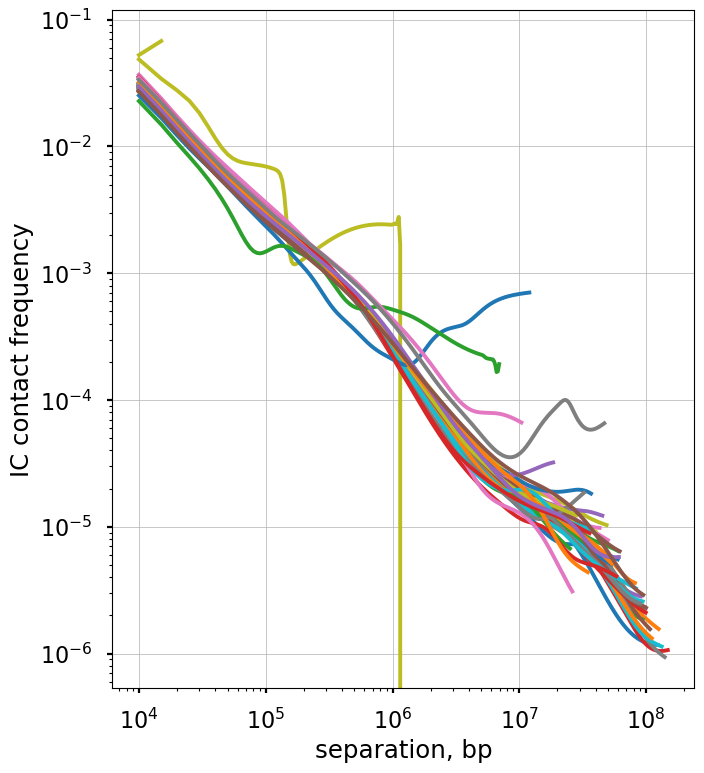

In [21]:
#plotting
cvd_smooth_agg_2['balanced.avg.smoothed'].loc[cvd_smooth_agg_2['dist'] < 2] = np.nan

f, ax = plt.subplots(1,1)

for region in hg38_arms['name']:
    ax.loglog(
        cvd_smooth_agg_2['dist_bp'].loc[cvd_smooth_agg_2['region1']==region],
        cvd_smooth_agg_2['balanced.avg.smoothed'].loc[cvd_smooth_agg_2['region1']==region],
    )
    ax.set(
        xlabel='separation, bp',
        ylabel='IC contact frequency')
    ax.set_aspect(1.0)
    ax.grid(lw=0.5)

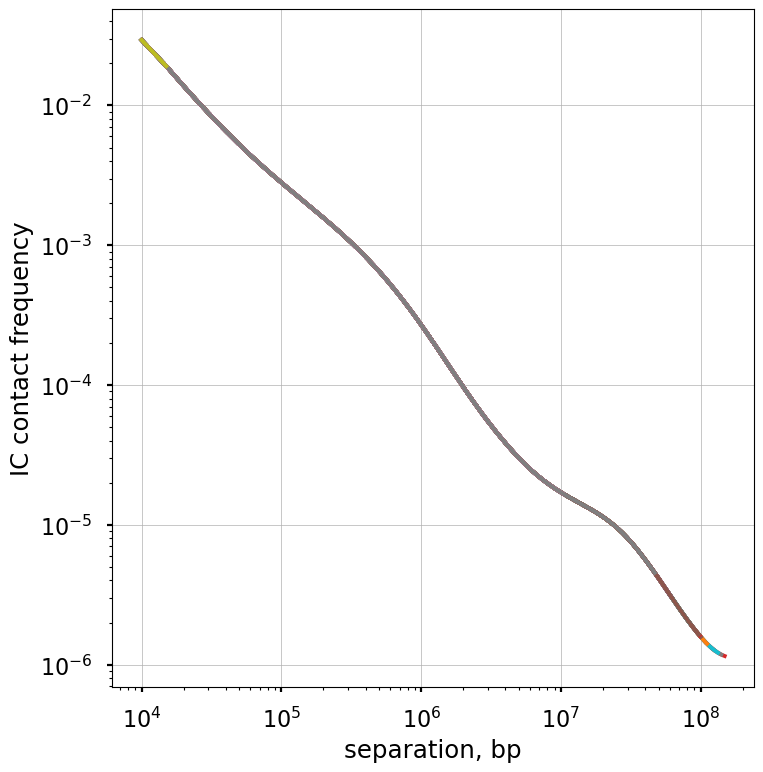

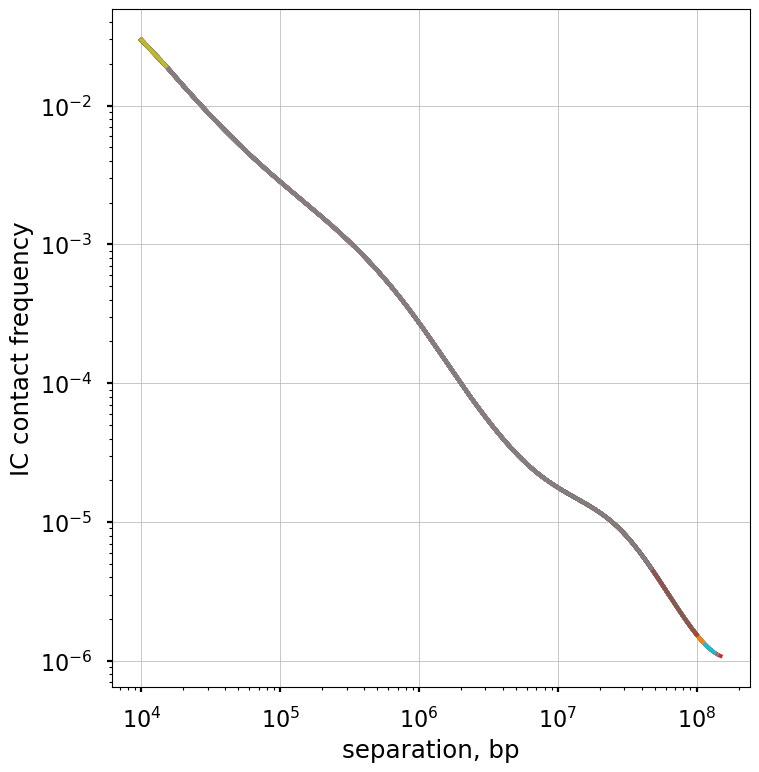

In [22]:
cvd_smooth_agg_1['balanced.avg.smoothed.agg'].loc[cvd_smooth_agg_1['dist'] < 2] = np.nan
f, ax = plt.subplots(1,1)

for region in hg38_arms['name']:
    ax.loglog(
        cvd_smooth_agg_1['dist_bp'].loc[cvd_smooth_agg_1['region1']==region],
        cvd_smooth_agg_1['balanced.avg.smoothed.agg'].loc[cvd_smooth_agg_1['region1']==region],
    )
    ax.set(
        xlabel='separation, bp',
        ylabel='IC contact frequency')
    ax.set_aspect(1.0)
    ax.grid(lw=0.5)

########

cvd_smooth_agg_2['balanced.avg.smoothed.agg'].loc[cvd_smooth_agg_2['dist'] < 2] = np.nan
f, ax = plt.subplots(1,1)

for region in hg38_arms['name']:
    ax.loglog(
        cvd_smooth_agg_2['dist_bp'].loc[cvd_smooth_agg_2['region1']==region],
        cvd_smooth_agg_2['balanced.avg.smoothed.agg'].loc[cvd_smooth_agg_2['region1']==region],
    )
    ax.set(
        xlabel='separation, bp',
        ylabel='IC contact frequency')
    ax.set_aspect(1.0)
    ax.grid(lw=0.5)

In [ ]:
# Plot the smoothed P(s) curve and its derivative

## do olater

### smoothed P(s) curve and its derivative

In [31]:
# Just take a single value for each genomic separation
cvd_merged_1 = cvd_smooth_agg_1.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]
cvd_merged_2 = cvd_smooth_agg_2.drop_duplicates(subset=['dist'])[['dist_bp', 'balanced.avg.smoothed.agg']]

In [32]:
# Calculate derivative in log-log space
der_1 = np.gradient(np.log(cvd_merged_1['balanced.avg.smoothed.agg']),
                  np.log(cvd_merged_1['dist_bp']))

der_2 = np.gradient(np.log(cvd_merged_2['balanced.avg.smoothed.agg']),
                  np.log(cvd_merged_2['dist_bp']))

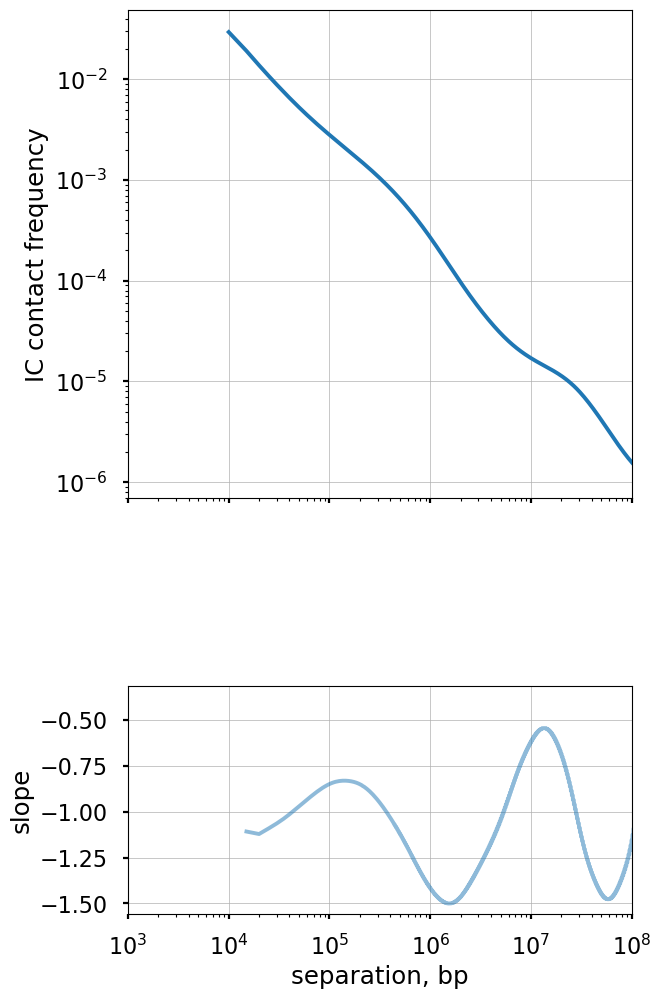

In [34]:
f, axs = plt.subplots(
    figsize=(6.5,13),
    nrows=2,
    gridspec_kw={'height_ratios':[6,2]},
    sharex=True)
ax = axs[0]
ax.loglog(
    cvd_merged_1['dist_bp'],
    cvd_merged_1['balanced.avg.smoothed.agg'],
    '-'
)

ax.set(
    ylabel='IC contact frequency',
    xlim=(1e3,1e8)
)
ax.set_aspect(1.0)
ax.grid(lw=0.5)


ax = axs[1]
ax.semilogx(
    cvd_merged_1['dist_bp'],
    der_1,
    alpha=0.5
)

ax.set(
    xlabel='separation, bp',
    ylabel='slope')

ax.grid(lw=0.5)

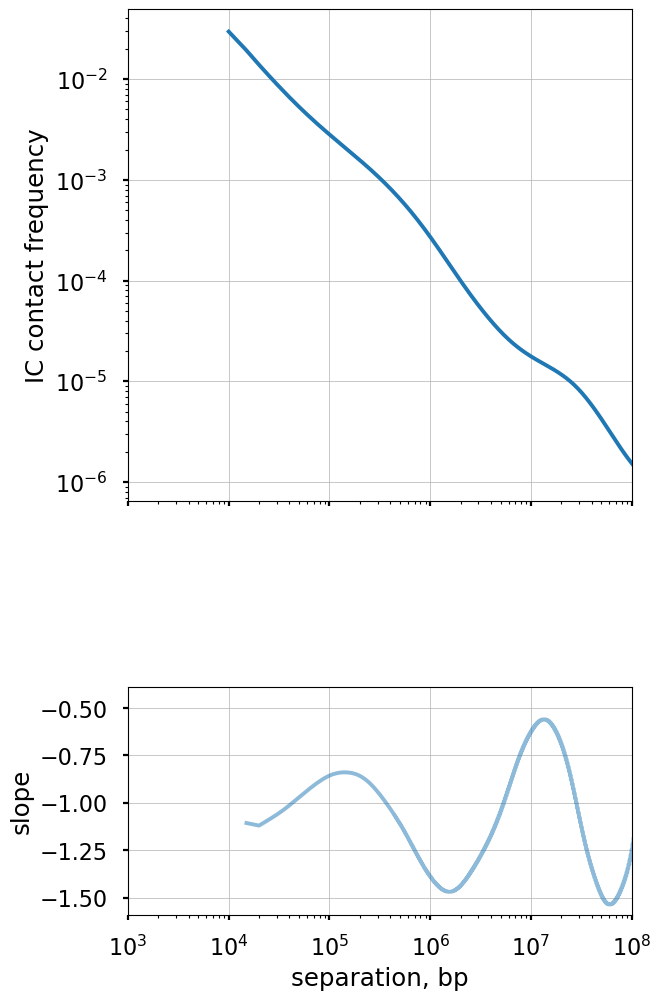

In [35]:
f, axs = plt.subplots(
    figsize=(6.5,13),
    nrows=2,
    gridspec_kw={'height_ratios':[6,2]},
    sharex=True)
ax = axs[0]
ax.loglog(
    cvd_merged_2['dist_bp'],
    cvd_merged_2['balanced.avg.smoothed.agg'],
    '-'
)

ax.set(
    ylabel='IC contact frequency',
    xlim=(1e3,1e8)
)
ax.set_aspect(1.0)
ax.grid(lw=0.5)


ax = axs[1]
ax.semilogx(
    cvd_merged_2['dist_bp'],
    der_2,
    alpha=0.5
)

ax.set(
    xlabel='separation, bp',
    ylabel='slope')

ax.grid(lw=0.5)

In [23]:
# cvd_inter == contacts-vs-distance between chromosomal arms
cvd_inter_1 = cooltools.expected_cis(
    clr=clr_1,
    view_df=hg38_arms,
    intra_only=False,
    nproc=num_cpus
)
# select only inter-arm interactions:
cvd_inter_1 = cvd_inter_1[ cvd_inter_1["region1"] != cvd_inter_1["region2"] ].reset_index(drop=True)

########

cvd_inter_2 = cooltools.expected_cis(
    clr=clr_2,
    view_df=hg38_arms,
    intra_only=False,
    nproc=num_cpus
)
# select only inter-arm interactions:
cvd_inter_2 = cvd_inter_2[ cvd_inter_2["region1"] != cvd_inter_2["region2"] ].reset_index(drop=True)


INFO:root:creating a Pool of 48 workers
INFO:root:creating a Pool of 48 workers


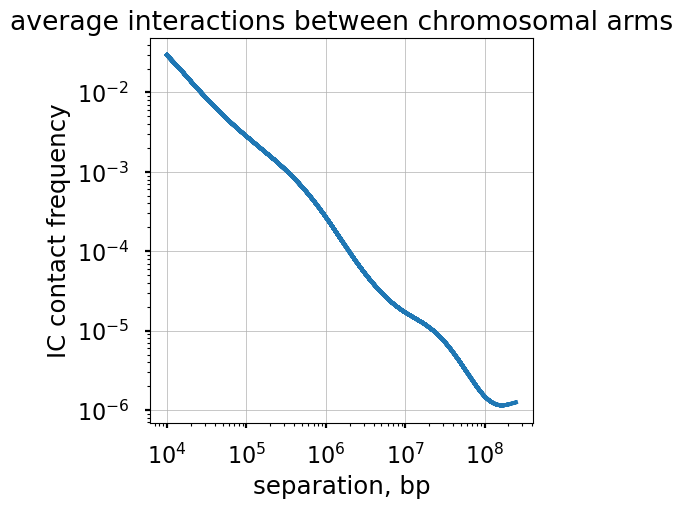

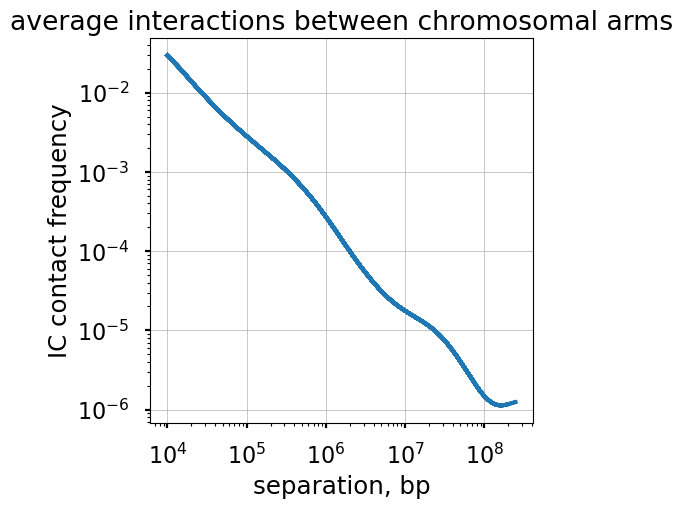

In [24]:
cvd_inter_1['balanced.avg.smoothed.agg'].loc[cvd_inter_1['dist'] < 2] = np.nan
f, ax = plt.subplots(1,1,
    figsize=(5,5),)

ax.loglog(
    cvd_inter_1['dist_bp'],
    cvd_inter_1['balanced.avg.smoothed.agg'],
)

ax.set(
    xlabel='separation, bp',
    ylabel='IC contact frequency',
    title="average interactions between chromosomal arms")
ax.grid(lw=0.5)
ax.set_aspect(1.0)

#####

cvd_inter_2['balanced.avg.smoothed.agg'].loc[cvd_inter_2['dist'] < 2] = np.nan
f, ax = plt.subplots(1,1,
    figsize=(5,5),)

ax.loglog(
    cvd_inter_2['dist_bp'],
    cvd_inter_2['balanced.avg.smoothed.agg'],
)

ax.set(
    xlabel='separation, bp',
    ylabel='IC contact frequency',
    title="average interactions between chromosomal arms")
ax.grid(lw=0.5)
ax.set_aspect(1.0)

### interaction frequencies in blocks

In [25]:
# average contacts, in this case between pairs of chromosomal arms:
ac_1 = cooltools.expected_trans(
    clr_1,
    view_df = None, # full chromosomes as the view
    nproc=num_cpus
)

# average raw interaction counts and normalized contact frequencies are already in the result
ac_1

########

ac_2 = cooltools.expected_trans(
    clr_1,
    view_df = None, # full chromosomes as the view
    nproc=num_cpus
)

# average raw interaction counts and normalized contact frequencies are already in the result
ac_2

INFO:root:creating a Pool of 48 workers
INFO:root:creating a Pool of 48 workers


,region1,region2,n_valid,count.sum,balanced.sum,count.avg,balanced.avg
0,chr1,chr2,1945188192,544195.0,447.884049,0.000280,2.302523e-07
1,chr1,chr3,1629800544,444350.0,385.288177,0.000273,2.364020e-07
2,chr1,chr4,1553803008,429924.0,363.678368,0.000277,2.340569e-07
3,chr1,chr5,1459816128,399063.0,354.839993,0.000273,2.430717e-07
4,chr1,chr6,1357111008,374960.0,332.705330,0.000276,2.451570e-07
...,...,...,...,...,...,...,...
295,chr22,chrY,22099660,27229.0,18.677788,0.001232,8.451618e-07
296,chr22,chrM,27368,14.0,0.021235,0.000512,7.759003e-07
297,chrX,chrY,91690010,17223.0,43.190535,0.000188,4.710495e-07
298,chrX,chrM,113548,77.0,0.150325,0.000678,1.323885e-06


In [27]:
acp_1 = (ac_1
    .pivot_table(values="balanced.avg",
                 index="region1",
                 columns="region2",
                 observed=True)
    .reindex(index=clr_1.chromnames,
             columns=clr_1.chromnames)
)

####

acp_2 = (ac_2
    .pivot_table(values="balanced.avg",
                 index="region1",
                 columns="region2",
                 observed=True)
    .reindex(index=clr_2.chromnames,
             columns=clr_2.chromnames)
)

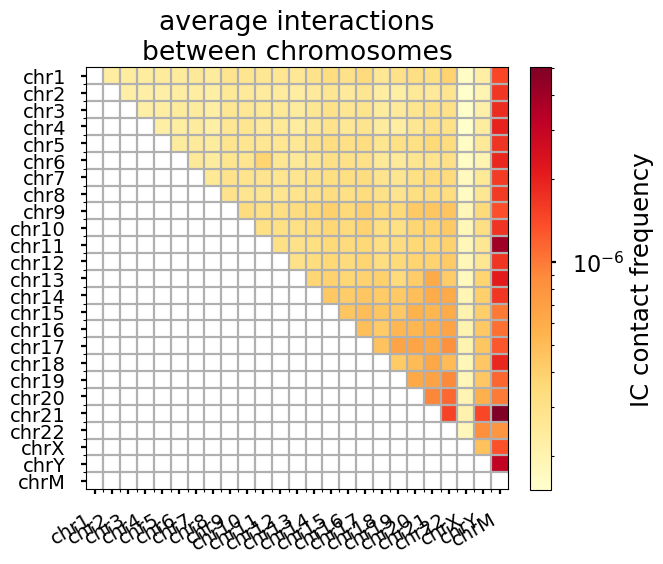

In [29]:
fs = 14

f, axs = plt.subplots(
    figsize=(6.0,5.5),
    ncols=2,
    gridspec_kw={'width_ratios':[20,1],"wspace":0.1},
)
# assign heatmap and colobar axis:
ax, cax = axs
# draw a heatmap, using log-scale for interaction freq-s:
acpm = ax.imshow(
    acp_1,
    cmap="YlOrRd",
    norm=colors.LogNorm(),
    aspect=1.0
)
# assign ticks and labels (ordered names of chromosome arms):
ax.set(
    xticks=range(len(clr_1.chromnames)),
    yticks=range(len(clr_1.chromnames)),
    title="average interactions\nbetween chromosomes",
)
ax.set_xticklabels(
    clr_1.chromnames,
    rotation=30,
    horizontalalignment='right',
    fontsize=fs
)
ax.set_yticklabels(
    clr_1.chromnames,
    fontsize=fs
)
# draw a colorbar of interaction frequencies for the heatmap:
f.colorbar(
    acpm,
    cax=cax,
    label='IC contact frequency'
)

# draw a grid around values:
ax.set_xticks(
    [x-0.5 for x in range(1,len(clr_1.chromnames))],
    minor=True
)
ax.set_yticks(
    [y-0.5 for y in range(1,len(clr_1.chromnames))],
    minor=True
)
ax.grid(which="minor")

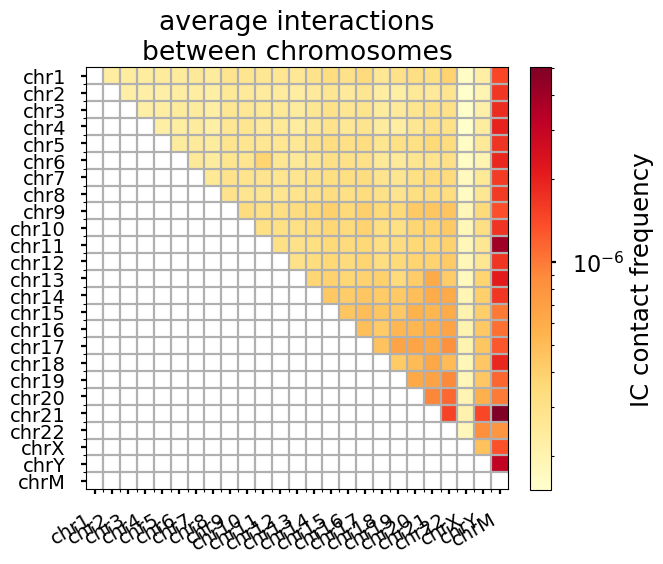

In [30]:
fs = 14

f, axs = plt.subplots(
    figsize=(6.0,5.5),
    ncols=2,
    gridspec_kw={'width_ratios':[20,1],"wspace":0.1},
)
# assign heatmap and colobar axis:
ax, cax = axs
# draw a heatmap, using log-scale for interaction freq-s:
acpm = ax.imshow(
    acp_2,
    cmap="YlOrRd",
    norm=colors.LogNorm(),
    aspect=1.0
)
# assign ticks and labels (ordered names of chromosome arms):
ax.set(
    xticks=range(len(clr_2.chromnames)),
    yticks=range(len(clr_2.chromnames)),
    title="average interactions\nbetween chromosomes",
)
ax.set_xticklabels(
    clr_2.chromnames,
    rotation=30,
    horizontalalignment='right',
    fontsize=fs
)
ax.set_yticklabels(
    clr_2.chromnames,
    fontsize=fs
)
# draw a colorbar of interaction frequencies for the heatmap:
f.colorbar(
    acpm,
    cax=cax,
    label='IC contact frequency'
)

# draw a grid around values:
ax.set_xticks(
    [x-0.5 for x in range(1,len(clr_2.chromnames))],
    minor=True
)
ax.set_yticks(
    [y-0.5 for y in range(1,len(clr_2.chromnames))],
    minor=True
)
ax.grid(which="minor")